# QualCheck – Training Pipeline (DREsS Edition)

**Camarines Sur Polytechnic Colleges – College of Computer Studies**

This notebook adapts the QualCheck pipeline to the **DREsS dataset** ([Yoo et al., 2025](https://aclanthology.org/2025.acl-long.659/)).

### DREsS → QualCheck conversion
| DREsS column | Role in QualCheck |
|---|---|
| `prompt` | `question` |
| `essay` | `response` |
| `score_content / score_organization / score_language` (1–5 float) | converted to `quality_label` (Fully Relevant / Partially Relevant / Irrelevant) |
| *(rubric text injected from DREsS paper)* | `rubric_descriptor` |
| *(one essay × 3 criteria = 3 rows)* | long-format dataset |

> **Expected CSV columns:** `id`, `prompt`, `essay`, `score_content`, `score_organization`, `score_language`  
> `source` and `total` columns are optional and ignored.

In [1]:
!pip install transformers torch scikit-learn pandas numpy nltk spacy scipy statsmodels matplotlib seaborn tqdm safetensors -q
!python -m spacy download en_core_web_sm -q

import nltk
nltk.download('punkt',     quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet',   quiet=True)
print('✓ Packages ready')

✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
✓ Packages ready


In [2]:
import os, json, warnings, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from tqdm.auto import tqdm
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import (BertTokenizer, BertModel,
                          get_linear_schedule_with_warmup)
from torch.optim import AdamW

from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, f1_score,
                              precision_score, recall_score)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity as tfidf_cos

from scipy.stats  import pearsonr, f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd

import nltk
from nltk.corpus import stopwords
from nltk.stem   import WordNetLemmatizer

import spacy
nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])

from safetensors.torch import save_file as _st_save_file, load_file as _st_load_file

def save_safetensors(state_dict, path):
    """Save a model state_dict as .safetensors.

    safetensors requires every tensor to own its storage (no shared/view
    memory), so each tensor is cloned to a contiguous CPU copy first.
    """
    clean = {k: v.detach().clone().contiguous().cpu() for k, v in state_dict.items()}
    _st_save_file(clean, path)

def load_safetensors(path, device):
    """Load a .safetensors checkpoint directly onto `device`."""
    return _st_load_file(path, device=str(device))

print('✓ Imports complete')


✓ Imports complete


## Configuration

In [3]:
class Config:
    # ── DREsS file paths ──────────────────────────────────────────
    # Point each to the sub-dataset CSV you downloaded from the consent link.
    # Set to None to skip that sub-dataset.
    PATH_NEW  = "datasets/Dress/DREsS_New.tsv"     # 2,279 expert-scored EFL essays
    PATH_STD  = "datasets/Dress/DREsS_Std.tsv"     # 6,515 essays from existing datasets
    PATH_CASE_CONTENT = "datasets/Dress/DREsS_CASE_content.tsv"    
    PATH_CASE_ORG = "datasets/Dress/DREsS_CASE_organization.tsv"
    PATH_CASE_LANG = "datasets/Dress/DREsS_CASE_language.tsv"

    # ── Which criteria to include (set False to drop a rubric dimension) ──
    USE_CONTENT      = True
    USE_ORGANIZATION = True
    USE_LANGUAGE     = True

    # ── Score → label conversion (1–5 scale with 0.5 increments) ─
    #   score ≥ THRESH_HIGH          → Fully Relevant
    #   THRESH_LOW ≤ score < HIGH    → Partially Relevant
    #   score < THRESH_LOW           → Irrelevant
    THRESH_HIGH = 4.0
    THRESH_LOW  = 2.5

    # ── Labels ───────────────────────────────────────────────────
    LABEL2ID = {"Fully Relevant": 2, "Partially Relevant": 1, "Irrelevant": 0}
    ID2LABEL = {2: "Fully Relevant",  1: "Partially Relevant", 0: "Irrelevant"}
    NUM_LABELS = 3

    # ── BERT ─────────────────────────────────────────────────────
    BERT_MODEL = "bert-base-uncased"
    MAX_LEN    = 256      # reduce to 128 if GPU memory is tight

    # ── Training ─────────────────────────────────────────────────
    BATCH_SIZE   = 16
    LR           = 2e-5
    MAX_EPOCHS   = 5
    PATIENCE     = 3
    WARMUP_RATIO = 0.1
    DROPOUT      = 0.3
    LAMBDA_SIM   = 2.0    # weight on the cosine-similarity regression term (see cell 19)

    # ── Split ────────────────────────────────────────────────────
    TRAIN_RATIO = 0.70
    VAL_RATIO   = 0.15
    TEST_RATIO  = 0.15
    SEED        = 42

    # ── Threshold calibration ────────────────────────────────────
    THRESH_STEP = 0.01

    # ── Output ───────────────────────────────────────────────────
    OUTPUT_DIR  = "essay_qualcheck"
    BEST_CKPT   = "essay_qualcheck/best_model.safetensors"
    FINAL_MODEL = "essay_qualcheck/qualcheck_final.safetensors"
    FINAL_META  = "essay_qualcheck/qualcheck_final_meta.json"   # non-tensor fields (θ1, θ2, label map, ...)

    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

cfg = Config()
os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)

random.seed(cfg.SEED); np.random.seed(cfg.SEED); torch.manual_seed(cfg.SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(cfg.SEED)

print(f"Device : {cfg.DEVICE}")
print(f"CUDA   : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU    : {torch.cuda.get_device_name(0)}")

Device : cuda
CUDA   : True
GPU    : NVIDIA RTX A5000


## Phase 1 – DREsS Data Loading & Adaptation

### Step 1 – Rubric Definitions (from DREsS paper)

In [4]:
# Rubric descriptors taken verbatim from the DREsS dataset paper (Yoo et al., 2025)
DRESS_RUBRICS = {
    "content": {
        "criterion" : "Content",
        "descriptor": (
            "Paragraph is well-developed and relevant to the argument, "
            "supported with strong reasons and examples. The response "
            "demonstrates thorough understanding of the topic and provides "
            "detailed, accurate, and well-supported ideas that fully address "
            "the essay prompt."
        ),
        "score_col"  : "score_content"
    },
    "organization": {
        "criterion" : "Organization",
        "descriptor": (
            "The argument is very effectively structured and developed, making "
            "it easy for the reader to follow the ideas and understand how the "
            "writer is building the argument. Paragraphs use coherence devices "
            "effectively while focusing on a single main idea. The essay has a "
            "clear introduction, body, and conclusion with smooth transitions."
        ),
        "score_col"  : "score_organization"
    },
    "language": {
        "criterion" : "Language",
        "descriptor": (
            "The writing displays sophisticated control of a wide range of "
            "vocabulary and collocations. The essay follows grammar and usage "
            "rules throughout the paper. Spelling and punctuation are correct "
            "throughout the paper. Word choice is precise, varied, and "
            "contextually appropriate."
        ),
        "score_col"  : "score_language"
    }
}

enabled_criteria = [k for k, v in {
    "content":      cfg.USE_CONTENT,
    "organization": cfg.USE_ORGANIZATION,
    "language":     cfg.USE_LANGUAGE
}.items() if v]

print("Enabled criteria:", enabled_criteria)
for k in enabled_criteria:
    print(f"\n  [{k}]  {DRESS_RUBRICS[k]['descriptor'][:80]}…")


Enabled criteria: ['content', 'organization', 'language']

  [content]  Paragraph is well-developed and relevant to the argument, supported with strong …

  [organization]  The argument is very effectively structured and developed, making it easy for th…

  [language]  The writing displays sophisticated control of a wide range of vocabulary and col…


### Step 1.5 – Dynamic Rubric Phrasing Pools

`DRESS_RUBRICS` above has exactly **one** fixed sentence per criterion — every row for "Content" (out of ~16k rows) trains on the identical string. That's a real weakness: the model can memorize that one exact phrasing instead of learning to generalize across different ways of expressing the same criterion, which matters because the admin panel UI lets professors type their own rubric wording, not the DREsS canonical text verbatim.

The pools below hold several paraphrases per criterion (same substantive meaning as the DREsS descriptor, reworded), drawn with a non-adjacent-repeat distribution during the melt step — the same technique already used for Code Report's synthetic descriptors and Short Answer's Key Concept/Clarity criteria.

In [5]:
CONTENT_TEMPLATES = [
    "The essay is well-developed and relevant to the argument, supported with "
    "strong reasons and examples.",
    "Does the response demonstrate thorough understanding of the topic with "
    "detailed, accurate, and well-supported ideas?",
    "The essay fully addresses the prompt with strong, well-supported "
    "reasoning.",
    "Are the ideas relevant, well-supported, and thoroughly developed in "
    "response to the prompt?",
    "The response provides accurate, well-supported ideas that fully address "
    "the essay prompt.",
]

ORGANIZATION_TEMPLATES = [
    "The argument is effectively structured, making it easy for the reader to "
    "follow the ideas.",
    "Does the essay use coherence devices effectively while keeping each "
    "paragraph focused on one main idea?",
    "The essay has a clear introduction, body, and conclusion with smooth "
    "transitions.",
    "Is the argument logically developed so the reader can follow how it's "
    "being built?",
    "The response is organized with clear structure and smooth transitions "
    "between ideas.",
]

LANGUAGE_TEMPLATES = [
    "The writing displays sophisticated control of a wide range of vocabulary "
    "and collocations.",
    "Does the essay follow grammar and usage rules with correct spelling and "
    "punctuation throughout?",
    "Word choice is precise, varied, and contextually appropriate.",
    "The response demonstrates strong command of vocabulary, grammar, and "
    "mechanics.",
    "Is the language sophisticated, grammatically correct, and free of "
    "spelling or punctuation errors?",
]

RUBRIC_TEMPLATE_POOLS = {
    "content"     : CONTENT_TEMPLATES,
    "organization": ORGANIZATION_TEMPLATES,
    "language"    : LANGUAGE_TEMPLATES,
}


def _non_adjacent_pick(pool, rng, last_idx):
    """Pick a random index from pool that differs from the previous pick for
    this criterion, so consecutive rows don't repeat the same phrasing."""
    idx = rng.randrange(len(pool))
    if len(pool) > 1:
        while idx == last_idx:
            idx = rng.randrange(len(pool))
    return idx, pool[idx]


rubric_rng       = random.Random(cfg.SEED)
rubric_last_idxs = {}   # tracks last pick per criterion_key

print("Example draws per criterion:")
for k in enabled_criteria:
    idx, text = _non_adjacent_pick(RUBRIC_TEMPLATE_POOLS[k], rubric_rng, rubric_last_idxs.get(k))
    rubric_last_idxs[k] = idx
    print(f"  [{k}]  {text[:80]}…")


Example draws per criterion:
  [content]  The essay is well-developed and relevant to the argument, supported with strong …
  [organization]  The argument is effectively structured, making it easy for the reader to follow …
  [language]  Word choice is precise, varied, and contextually appropriate.…


### Step 2 – Load & Validate DREsS CSVs

In [6]:
def load_dress_tsv(path, source_tag):
    """Load one DREsS sub-dataset TSV and normalise column names."""
    if path is None or not os.path.exists(path):
        print(f"  [skip] {path} not found")
        return None

    df = pd.read_csv(path, sep='\t')
    print(f"  Loaded {path}  →  {df.shape}  columns: {df.columns.tolist()}")

    # Normalise to expected column names
    rename = {}
    for col in df.columns:
        cl = col.lower().strip().replace(" ", "_")
        # prompt / essay
        if cl in ("prompt",):           rename[col] = "prompt"
        elif cl in ("essay",):          rename[col] = "essay"
        # scores – handle both 'score_content' and nested 'score.content'
        elif "content"      in cl and "score" in cl: rename[col] = "score_content"
        elif "organization" in cl and "score" in cl: rename[col] = "score_organization"
        elif "organisation" in cl and "score" in cl: rename[col] = "score_organization"
        elif "language"     in cl and "score" in cl: rename[col] = "score_language"

    df = df.rename(columns=rename)
    df["_source"] = source_tag
    return df

print("Loading DREsS sub-datasets …")
frames = []
for path, tag in [(cfg.PATH_NEW,  "DREsS_New"),
                  (cfg.PATH_STD,  "DREsS_Std"),
                  (cfg.PATH_CASE_CONTENT, "DREsS_CASE_content"),
                  (cfg.PATH_CASE_ORG, "DREsS_CASE_organization"),
                  (cfg.PATH_CASE_LANG, "DREsS_CASE_language")]:
    f = load_dress_tsv(path, tag)
    if f is not None:
        frames.append(f)

assert frames, "No DREsS TSV files found – check PATH_NEW / PATH_STD / PATH_CASE_* in Config"
raw_df = pd.concat(frames, ignore_index=True)
print(f"\nCombined shape : {raw_df.shape}")
print(f"Columns        : {raw_df.columns.tolist()}")
print(f"Sub-datasets   : {raw_df['_source'].value_counts().to_dict()}")

Loading DREsS sub-datasets …
  Loaded datasets/Dress/DREsS_New.tsv  →  (2279, 7)  columns: ['id', 'prompt', 'essay', 'content', 'organization', 'language', 'total']
  Loaded datasets/Dress/DREsS_Std.tsv  →  (6508, 8)  columns: ['id', 'source', 'prompt', 'essay', 'content', 'organization', 'language', 'total']
  Loaded datasets/Dress/DREsS_CASE_content.tsv  →  (8307, 4)  columns: ['id', 'prompt', 'essay', 'content']
  Loaded datasets/Dress/DREsS_CASE_organization.tsv  →  (31086, 4)  columns: ['id', 'prompt', 'essay', 'organization']
  Loaded datasets/Dress/DREsS_CASE_language.tsv  →  (792, 4)  columns: ['id', 'prompt', 'essay', 'language']

Combined shape : (48972, 9)
Columns        : ['id', 'prompt', 'essay', 'content', 'organization', 'language', 'total', '_source', 'source']
Sub-datasets   : {'DREsS_CASE_organization': 31086, 'DREsS_CASE_content': 8307, 'DREsS_Std': 6508, 'DREsS_New': 2279, 'DREsS_CASE_language': 792}


### Step 3 – Convert Scores → 3-Class Labels & Melt to Long Format

In [7]:
# ── Diagnostic block – insert BEFORE the real loop ──────────────────
print("=== RAW DF SHAPE:", raw_df.shape)
print("=== COLUMNS:", raw_df.columns.tolist())
print("=== enabled_criteria:", enabled_criteria)

# Check a sample row
sample = raw_df.iloc[0]
print("\n=== SAMPLE ROW KEYS:", sample.index.tolist())
print("  prompt repr:", repr(str(sample.get("prompt","")).strip())[:80])
print("  essay  repr:", repr(str(sample.get("essay", "")).strip())[:80])

for k in enabled_criteria:
    rubric_info = DRESS_RUBRICS[k]
    score_col   = rubric_info["score_col"]
    raw_score   = sample.get(score_col, "MISSING_KEY")
    label       = score_to_label(raw_score) if raw_score != "MISSING_KEY" else "NO_COL"
    print(f"  criterion={k!r:20s}  score_col={score_col!r:25s}  raw={raw_score!r}  label={label!r}")

=== RAW DF SHAPE: (48972, 9)
=== COLUMNS: ['id', 'prompt', 'essay', 'content', 'organization', 'language', 'total', '_source', 'source']
=== enabled_criteria: ['content', 'organization', 'language']

=== SAMPLE ROW KEYS: ['id', 'prompt', 'essay', 'content', 'organization', 'language', 'total', '_source', 'source']
  prompt repr: 'Univeristy: Some people believe that university students should be required to 
  essay  repr: 'Many university classes requires the attendance in the class so that it is incl
  criterion='content'             score_col='score_content'            raw='MISSING_KEY'  label='NO_COL'
  criterion='organization'        score_col='score_organization'       raw='MISSING_KEY'  label='NO_COL'
  criterion='language'            score_col='score_language'           raw='MISSING_KEY'  label='NO_COL'


Long-format rows : 66,546  (skipped 0 essays with blank fields)

Label distribution:
quality_label
Partially Relevant    29503
Fully Relevant        19399
Irrelevant            17644

Per-criterion:
quality_label  Fully Relevant  Irrelevant  Partially Relevant
criterion_key                                                
content                  5151        3987                7956
language                 1493        2093                5993
organization            12755       11564               15554


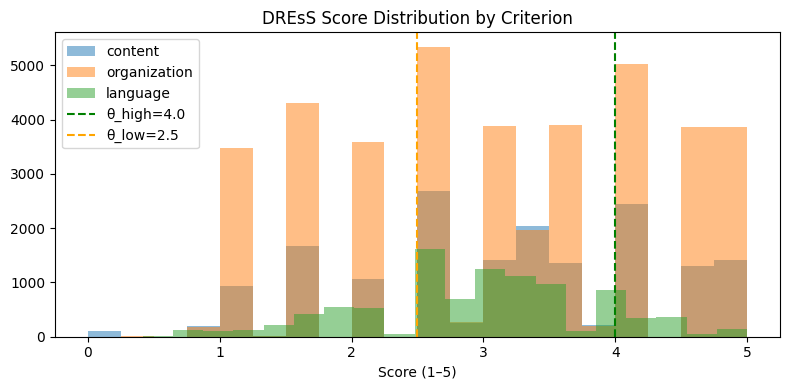

In [8]:
def score_to_label(score, high=cfg.THRESH_HIGH, low=cfg.THRESH_LOW):
    """Map a 1–5 float score to one of the three QualCheck relevance labels."""
    if pd.isna(score):
        return None
    if score >= high:
        return "Fully Relevant"
    elif score >= low:
        return "Partially Relevant"
    else:
        return "Irrelevant"

# Melt: one essay × N criteria  →  N rows ──────────────────────────
long_rows = []
skipped_essays = 0

for _, row in raw_df.iterrows():
    prompt = str(row.get("prompt", "")).strip()
    essay  = str(row.get("essay",  "")).strip()

    if not prompt or not essay:
        skipped_essays += 1
        continue

    for criterion_key in enabled_criteria:
        rubric_info = DRESS_RUBRICS[criterion_key]
        score_col   = criterion_key          # ← FIX: columns are 'content', 'organization', 'language'

        raw_score = row.get(score_col, None)
        label     = score_to_label(raw_score)

        if label is None:          # missing score for this criterion – skip row
            continue

        # Draw a paraphrase instead of the single fixed DRESS descriptor,
        # so the model sees varied phrasing per criterion rather than one
        # memorizable string repeated across every row (see Step 1.5).
        pick_idx, rubric_text = _non_adjacent_pick(
            RUBRIC_TEMPLATE_POOLS[criterion_key], rubric_rng, rubric_last_idxs.get(criterion_key)
        )
        rubric_last_idxs[criterion_key] = pick_idx

        long_rows.append({
            "question"            : prompt,
            "evaluation_criterion": rubric_info["criterion"],
            "rubric_descriptor"   : rubric_text,
            "full_rubric"         : rubric_info["criterion"] + ". " + rubric_text,
            "response"            : essay,
            "raw_score"           : float(raw_score),
            "quality_label"       : label,
            "label_id"            : cfg.LABEL2ID[label],
            "output_type"         : "essay",
            "criterion_key"       : criterion_key,
            "_source"             : row["_source"]
        })

EXPECTED_COLS = [
    "question", "evaluation_criterion", "rubric_descriptor", "full_rubric",
    "response", "raw_score", "quality_label", "label_id",
    "output_type", "criterion_key", "_source"
]

df = pd.DataFrame(long_rows, columns=EXPECTED_COLS)

if df.empty:
    raise RuntimeError(
        f"No rows collected after melt. "
        f"skipped_essays={skipped_essays}, raw_df shape={raw_df.shape}. "
        f"Check that criterion keys {enabled_criteria} exist as columns in raw_df."
    )

print(f"Long-format rows : {len(df):,}  (skipped {skipped_essays} essays with blank fields)")
print(f"\nLabel distribution:")
print(df["quality_label"].value_counts().to_string())
print(f"\nPer-criterion:")
print(df.groupby(["criterion_key", "quality_label"]).size().unstack(fill_value=0).to_string())

# Score distribution overview
fig, ax = plt.subplots(figsize=(8, 4))
for k in enabled_criteria:
    subset = df[df["criterion_key"] == k]["raw_score"]
    ax.hist(subset, bins=20, alpha=0.5, label=k)
ax.axvline(cfg.THRESH_HIGH, color="green",  linestyle="--", label=f"θ_high={cfg.THRESH_HIGH}")
ax.axvline(cfg.THRESH_LOW,  color="orange", linestyle="--", label=f"θ_low={cfg.THRESH_LOW}")
ax.set_title("DREsS Score Distribution by Criterion")
ax.legend()
ax.set_xlabel("Score (1–5)")
plt.tight_layout()
plt.savefig(f"{cfg.OUTPUT_DIR}/dress_score_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

### Step 3.5 – Synthetic Topic-Mismatch Negatives

**Why:** DREsS labels `Irrelevant` purely from a low content/organization/language
*quality* score on an essay written for the correct prompt. Every training row is
an essay paired with its own prompt — the model never sees a well-written essay
paired with the *wrong* prompt, so it has no signal to distinguish "low quality"
from "wrong topic entirely." Confirmed via manual testing: a fluent, well-organized
but completely off-topic essay was scored 87.5% ("Partially Relevant") instead of
Irrelevant, while a genuinely on-topic but poorly-written essay correctly scored
near 0%.

**Fix:** sample existing Fully/Partially Relevant essays (i.e. essays that ARE
well-written) and re-pair each with a *different* prompt drawn from elsewhere in
the dataset, force-labeled Irrelevant. This teaches topical alignment as a signal
distinct from writing quality — something the original label distribution never
provided.

In [9]:
# ── Synthetic topic-mismatch negatives ──────────────────────────────
AUGMENT_ENABLED = True     # set False to reproduce the original (pre-fix) run
AUGMENT_RATIO   = 0.15     # synthetic rows added, as a fraction of current df size
AUGMENT_SEED    = cfg.SEED

if AUGMENT_ENABLED:
    aug_rng = np.random.default_rng(AUGMENT_SEED)

    # Only draw from genuinely well-written essays — pairing an already-weak
    # essay with the wrong prompt teaches nothing new, the model already scores
    # those low. We specifically want "good writing, wrong topic" examples.
    candidate_pool = df[df["quality_label"].isin(["Fully Relevant", "Partially Relevant"])]

    n_aug = int(len(df) * AUGMENT_RATIO)
    sampled = candidate_pool.sample(n=n_aug, random_state=AUGMENT_SEED, replace=(n_aug > len(candidate_pool)))

    all_questions = df["question"].unique()

    aug_rows = []
    for _, row in sampled.iterrows():
        # Pick a genuinely different prompt (retry on the rare collision)
        mismatched_q = row["question"]
        for _ in range(10):
            candidate_q = aug_rng.choice(all_questions)
            if candidate_q != row["question"]:
                mismatched_q = candidate_q
                break

        aug_rows.append({
            "question"            : mismatched_q,        # <- swapped, essay unchanged
            "evaluation_criterion": row["evaluation_criterion"],
            "rubric_descriptor"   : row["rubric_descriptor"],
            "full_rubric"         : row["full_rubric"],
            "response"            : row["response"],     # essay itself is untouched
            "raw_score"           : 1.0,                  # bottom of the 1-5 scale — forced Irrelevant
            "quality_label"       : "Irrelevant",
            "label_id"            : cfg.LABEL2ID["Irrelevant"],
            "output_type"         : "essay",
            "criterion_key"       : row["criterion_key"],
            "_source"             : "synthetic_topic_mismatch",
        })

    aug_df = pd.DataFrame(aug_rows, columns=EXPECTED_COLS)
    df = pd.concat([df, aug_df], ignore_index=True)

    print(f"Added {len(aug_df):,} synthetic topic-mismatch rows "
          f"({AUGMENT_RATIO:.0%} of pre-augmentation size)")
    print(f"\nLabel distribution AFTER augmentation:")
    print(df["quality_label"].value_counts().to_string())
else:
    print("AUGMENT_ENABLED=False — training on original DREsS labels only.")

Added 9,981 synthetic topic-mismatch rows (15% of pre-augmentation size)

Label distribution AFTER augmentation:
quality_label
Partially Relevant    29503
Irrelevant            27625
Fully Relevant        19399


### Step 4 – Text Preprocessing (NLTK + spaCy)

In [10]:
class TextPreprocessor:
    def __init__(self):
        self.lemmatizer = WordNetLemmatizer()
        self.stop_words = set(stopwords.words("english"))

    def clean_for_bert(self, text):
        return str(text).strip() if not pd.isna(text) else ""

    def deep_clean(self, text):
        """Lower → NLTK tokenise → drop stopwords → spaCy lemmatise (for TF-IDF baseline).

        Per Chapter 3 Phase 1, preprocessing combines NLTK (tokenization,
        lowercasing, stopword removal) with spaCy (lemmatization).
        """
        if pd.isna(text):
            return ""
        tokens   = nltk.word_tokenize(str(text).lower())
        filtered = [t for t in tokens if t.isalnum() and t not in self.stop_words]
        doc      = nlp(" ".join(filtered))
        return " ".join(tok.lemma_ for tok in doc if tok.lemma_.strip())

prep = TextPreprocessor()

df["clean_question"]  = df["question"].apply(prep.clean_for_bert)
df["clean_rubric"]    = df["rubric_descriptor"].apply(prep.clean_for_bert)
df["clean_response"]  = df["response"].apply(prep.clean_for_bert)

df["tfidf_question"]  = df["question"].apply(prep.deep_clean)
df["tfidf_rubric"]    = df["full_rubric"].apply(prep.deep_clean)
df["tfidf_response"]  = df["response"].apply(prep.deep_clean)

print(f"✓ Preprocessing complete  –  {len(df):,} rows")
print("\nSample entry:")
print(df[["criterion_key","raw_score","quality_label","clean_response"]].iloc[0].to_string())


✓ Preprocessing complete  –  76,527 rows

Sample entry:
criterion_key                                               content
raw_score                                                       3.5
quality_label                                    Partially Relevant
clean_response    Many university classes requires the attendanc...


### Step 5 – Stratified 70 / 15 / 15 Split

In [11]:
# Stratify on (label_id, criterion_key) to keep class balance per criterion
df["strat_key"] = df["label_id"].astype(str) + "_" + df["criterion_key"]

train_df, temp_df = train_test_split(df,
    test_size  = cfg.VAL_RATIO + cfg.TEST_RATIO,
    stratify   = df["strat_key"],
    random_state = cfg.SEED)

val_df, test_df = train_test_split(temp_df,
    test_size  = 0.5,
    stratify   = temp_df["strat_key"],
    random_state = cfg.SEED)

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

N = len(df)
print(f"Train : {len(train_df):>7,}  ({len(train_df)/N*100:.1f}%)")
print(f"Val   : {len(val_df):>7,}  ({len(val_df)/N*100:.1f}%)")
print(f"Test  : {len(test_df):>7,}  ({len(test_df)/N*100:.1f}%)")

print("\nTrain label distribution:")
print(train_df["quality_label"].value_counts().to_string())


Train :  53,568  (70.0%)
Val   :  11,479  (15.0%)
Test  :  11,480  (15.0%)

Train label distribution:
quality_label
Partially Relevant    20652
Irrelevant            19337
Fully Relevant        13579


## Phase 2 – BERT Encoding & Fine-Tuning

In [12]:
class QualCheckDataset(Dataset):
    """
    P  →  [CLS] question [SEP] full_rubric [SEP]
    R  →  [CLS] response [SEP]
    """
    def __init__(self, dataframe, tokenizer, max_len):
        self.df        = dataframe.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):  return len(self.df)

    def _enc(self, a, b=None):
        return self.tokenizer(          # ← FIX: was self.tokenizer.encode_plus(
            a, b,
            add_special_tokens    = True,
            max_length            = self.max_len,
            padding               = "max_length",
            truncation            = True,
            return_attention_mask = True,
            return_tensors        = "pt"
        )

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        pr  = self._enc(row["clean_question"], row["full_rubric"])
        r   = self._enc(row["clean_response"])
        return {
            "pr_ids"  : pr["input_ids"].squeeze(0),
            "pr_mask" : pr["attention_mask"].squeeze(0),
            "r_ids"   : r["input_ids"].squeeze(0),
            "r_mask"  : r["attention_mask"].squeeze(0),
            "label"   : torch.tensor(row["label_id"], dtype=torch.long)
        }

In [13]:
class QualCheckModel(nn.Module):
    """Siamese BERT with a 4-feature classification head."""

    def __init__(self, bert_name, num_labels=3, dropout=0.3):
        super().__init__()
        self.bert      = BertModel.from_pretrained(bert_name)
        hidden         = self.bert.config.hidden_size   # 768
        self.dropout   = nn.Dropout(dropout)
        self.classifier = nn.Sequential(
            nn.Linear(hidden * 4, hidden),
            nn.Tanh(),
            nn.Dropout(dropout),
            nn.Linear(hidden, num_labels)
        )

    def encode(self, input_ids, attention_mask):
        out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        return self.dropout(out.last_hidden_state[:, 0, :])

    def forward(self, pr_ids, pr_mask, r_ids, r_mask):
        p       = self.encode(pr_ids,  pr_mask)
        r       = self.encode(r_ids,   r_mask)
        cos_sim = F.cosine_similarity(p, r, dim=1, eps=1e-8)
        feat    = torch.cat([p, r, torch.abs(p - r), p * r], dim=1)
        logits  = self.classifier(feat)
        return logits, cos_sim, p, r

    @torch.no_grad()
    def similarity(self, pr_ids, pr_mask, r_ids, r_mask):
        p = self.encode(pr_ids,  pr_mask)
        r = self.encode(r_ids,   r_mask)
        return F.cosine_similarity(p, r, dim=1, eps=1e-8)


In [14]:
criterion_loss = nn.CrossEntropyLoss()

def sim_targets(labels, num_labels):
    """Map integer class labels {0,1,2} to the [0,1] similarity targets the
    cosine score is supposed to hit (0.0 / 0.5 / 1.0 for 3 classes) — the
    same normalization used for MAE/RMSE against human ratings later."""
    return labels.float() / (num_labels - 1)

def train_epoch(model, loader, opt, sch, device, num_labels, lambda_sim):
    model.train()
    total_loss = correct = n = 0
    for batch in tqdm(loader, desc="  Train", leave=False):
        pr_ids  = batch["pr_ids"].to(device);  pr_mask = batch["pr_mask"].to(device)
        r_ids   = batch["r_ids"].to(device);   r_mask  = batch["r_mask"].to(device)
        labels  = batch["label"].to(device)

        opt.zero_grad()
        logits, cos_sim, _, _ = model(pr_ids, pr_mask, r_ids, r_mask)
        ce_loss  = criterion_loss(logits, labels)
        # Regression term: directly supervises cos(P,R) itself, since Phase 3/4
        # of the pipeline classify using raw cosine similarity, not the head.
        sim_loss = F.mse_loss(cos_sim, sim_targets(labels, num_labels))
        loss = ce_loss + lambda_sim * sim_loss
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step(); sch.step()

        total_loss += loss.item() * labels.size(0)
        correct    += (logits.argmax(1) == labels).sum().item()
        n          += labels.size(0)
    return total_loss / n, correct / n

@torch.no_grad()
def evaluate(model, loader, device, num_labels, lambda_sim):
    model.eval()
    total_loss = correct = n = 0
    preds_all = []; labels_all = []; sims_all = []
    for batch in tqdm(loader, desc="  Eval ", leave=False):
        pr_ids  = batch["pr_ids"].to(device);  pr_mask = batch["pr_mask"].to(device)
        r_ids   = batch["r_ids"].to(device);   r_mask  = batch["r_mask"].to(device)
        labels  = batch["label"].to(device)
        logits, cos_sim, _, _ = model(pr_ids, pr_mask, r_ids, r_mask)
        ce_loss  = criterion_loss(logits, labels)
        sim_loss = F.mse_loss(cos_sim, sim_targets(labels, num_labels))
        loss = ce_loss + lambda_sim * sim_loss
        total_loss += loss.item() * labels.size(0)
        preds = logits.argmax(1)
        correct += (preds == labels).sum().item(); n += labels.size(0)
        preds_all.extend(preds.cpu().tolist());   labels_all.extend(labels.cpu().tolist())
        sims_all.extend(cos_sim.cpu().tolist())
    wf1 = f1_score(labels_all, preds_all, average="weighted", zero_division=0)
    # Pearson r between raw cosine similarity and true labels — this is the
    # metric that actually predicts Phase 3/4 test-set performance, since
    # extract_sims() uses the same raw cos(P,R) downstream.
    sim_r = np.corrcoef(sims_all, labels_all)[0, 1] if len(set(labels_all)) > 1 else float("nan")
    return total_loss/n, correct/n, wf1, sim_r

@torch.no_grad()
def extract_sims(model, dataframe, tokenizer, cfg):
    ds     = QualCheckDataset(dataframe, tokenizer, cfg.MAX_LEN)
    loader = DataLoader(ds, batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=2)
    sims, lbls = [], []
    for batch in tqdm(loader, desc="  Embed", leave=False):
        cos = model.similarity(
            batch["pr_ids"].to(cfg.DEVICE), batch["pr_mask"].to(cfg.DEVICE),
            batch["r_ids"].to(cfg.DEVICE),  batch["r_mask"].to(cfg.DEVICE))
        sims.extend(cos.cpu().tolist())
        lbls.extend(batch["label"].tolist())
    return np.array(sims), np.array(lbls)


### Run Fine-Tuning

In [15]:
tokenizer = BertTokenizer.from_pretrained(cfg.BERT_MODEL)
model     = QualCheckModel(cfg.BERT_MODEL, cfg.NUM_LABELS, cfg.DROPOUT).to(cfg.DEVICE)

train_loader = DataLoader(QualCheckDataset(train_df, tokenizer, cfg.MAX_LEN),
                          batch_size=cfg.BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(QualCheckDataset(val_df,   tokenizer, cfg.MAX_LEN),
                          batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=2)

total_steps  = len(train_loader) * cfg.MAX_EPOCHS
optimiser    = AdamW(model.parameters(), lr=cfg.LR, eps=1e-8, weight_decay=0.01)
scheduler    = get_linear_schedule_with_warmup(
                   optimiser, int(total_steps * cfg.WARMUP_RATIO), total_steps)

history = {k: [] for k in ["tr_loss","tr_acc","val_loss","val_acc","val_wf1","val_r"]}
# Per Chapter 3 Phase 2: early stopping (and best-checkpoint selection) is
# driven by validation LOSS, not validation Weighted F1. That loss now
# includes the cosine-similarity regression term (see cell 19), so it
# actually tracks the objective Phase 3/4 rely on downstream.
best_val_loss = float("inf"); best_wf1 = 0.0; best_val_r = float("nan"); no_improve = 0

print(f"Training  |  device={cfg.DEVICE}  |  steps={total_steps}")
print("="*60)
for epoch in range(cfg.MAX_EPOCHS):
    tr_loss, tr_acc                     = train_epoch(model, train_loader, optimiser, scheduler,
                                                        cfg.DEVICE, cfg.NUM_LABELS, cfg.LAMBDA_SIM)
    val_loss, val_acc, val_wf1, val_r   = evaluate(model, val_loader, cfg.DEVICE,
                                                     cfg.NUM_LABELS, cfg.LAMBDA_SIM)
    for k, v in zip(["tr_loss","tr_acc","val_loss","val_acc","val_wf1","val_r"],
                    [tr_loss, tr_acc, val_loss, val_acc, val_wf1, val_r]):
        history[k].append(v)

    tag = ""
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_wf1      = val_wf1
        best_val_r    = val_r
        os.makedirs(os.path.dirname(cfg.BEST_CKPT), exist_ok=True)   # guard: dir may not exist yet
        save_safetensors(model.state_dict(), cfg.BEST_CKPT)
        tag = "  ← best (lowest val_loss)"
        no_improve = 0
    else:
        no_improve += 1

    print(f"Ep {epoch+1}  tr_loss={tr_loss:.4f}  tr_acc={tr_acc:.4f}  ",
          f"val_loss={val_loss:.4f}  val_acc={val_acc:.4f}  val_wf1={val_wf1:.4f}  val_r(cos_sim)={val_r:.4f}{tag}")

    if no_improve >= cfg.PATIENCE:
        print(f"Early stopping at epoch {epoch+1} (no val_loss improvement for {cfg.PATIENCE} epochs)"); break

print(f"\nBest Val Loss        : {best_val_loss:.4f}")
print(f"Best Val Weighted-F1 : {best_wf1:.4f}  (at best-val-loss checkpoint)")
print(f"Best Val Pearson r   : {best_val_r:.4f}  (cos_sim vs. label — the metric Phase 3/4 actually rely on)")


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Training  |  device=cuda  |  steps=16740


  Train:   0%|          | 0/3348 [00:00<?, ?it/s]

  Eval :   0%|          | 0/718 [00:00<?, ?it/s]

...

Ep 4  tr_loss=0.5772  tr_acc=0.8141   val_loss=1.2934  val_acc=0.6676  val_wf1=0.6662  val_r(cos_sim)=0.6869


  Train:   0%|          | 0/3348 [00:00<?, ?it/s]

  Eval :   0%|          | 0/718 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x79592d970f40>
Traceback (most recent call last):
  File "/home/marcdextersael/miniconda3/envs/sabio/lib/python3.11/site-packages/torch/utils/data/dataloader.py", line 1604, in __del__
    self._shutdown_workers()
  File "/home/marcdextersael/miniconda3/envs/sabio/lib/python3.11/site-packages/torch/utils/data/dataloader.py", line 1587, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/home/marcdextersael/miniconda3/envs/sabio/lib/python3.11/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x79592d970f40>
Traceback (most recent call last):
  File "/home/marcdextersael/miniconda3/envs/sabio/lib/python3.11/site-packages/torch/utils/data/dataloader.py", line 

Ep 5  tr_loss=0.4686  tr_acc=0.8598   val_loss=1.3462  val_acc=0.6805  val_wf1=0.6797  val_r(cos_sim)=0.6882
Early stopping at epoch 5 (no val_loss improvement for 3 epochs)

Best Val Loss        : 1.0822
Best Val Weighted-F1 : 0.6498  (at best-val-loss checkpoint)
Best Val Pearson r   : 0.6773  (cos_sim vs. label — the metric Phase 3/4 actually rely on)


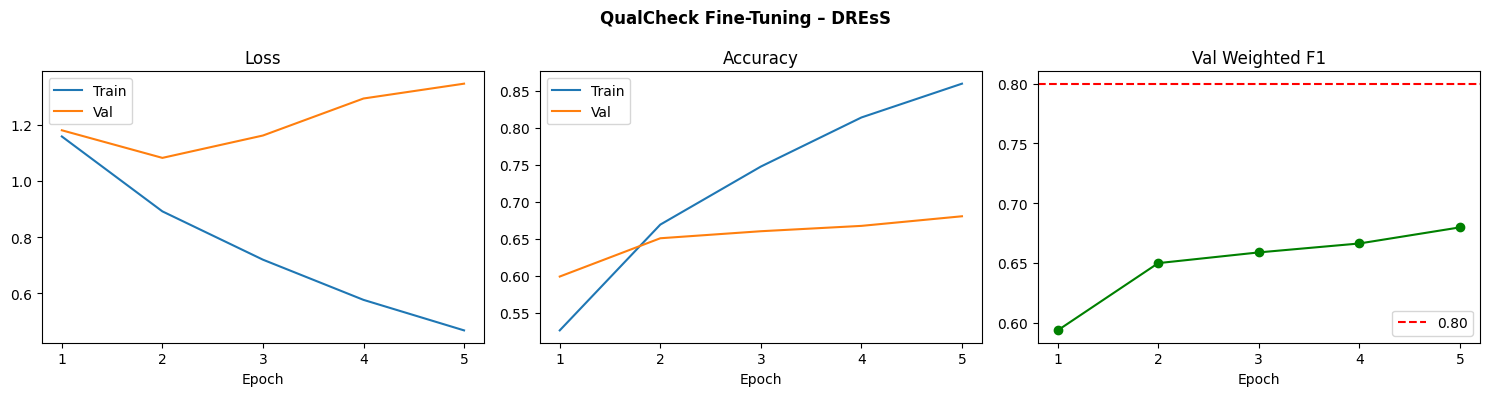

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
ep = range(1, len(history["tr_loss"])+1)
axes[0].plot(ep, history["tr_loss"], label="Train"); axes[0].plot(ep, history["val_loss"], label="Val")
axes[0].set_title("Loss"); axes[0].legend()
axes[1].plot(ep, history["tr_acc"],  label="Train"); axes[1].plot(ep, history["val_acc"],  label="Val")
axes[1].set_title("Accuracy"); axes[1].legend()
axes[2].plot(ep, history["val_wf1"], color="green", marker="o")
axes[2].axhline(0.80, color="red", linestyle="--", label="0.80"); axes[2].set_title("Val Weighted F1"); axes[2].legend()
for ax in axes: ax.set_xlabel("Epoch"); ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.suptitle("QualCheck Fine-Tuning – DREsS", fontweight="bold"); plt.tight_layout()
plt.savefig(f"{cfg.OUTPUT_DIR}/training_history.png", dpi=150, bbox_inches="tight"); plt.show()


## Phase 3 – Cosine Similarity Scoring

In [17]:
model.load_state_dict(load_safetensors(cfg.BEST_CKPT, cfg.DEVICE))
model.eval()

print("Extracting cosine similarities …")
val_sims,  val_true  = extract_sims(model, val_df,  tokenizer, cfg)
test_sims, test_true = extract_sims(model, test_df, tokenizer, cfg)

print(f"Val  sims  –  min={val_sims.min():.4f}  max={val_sims.max():.4f}  mean={val_sims.mean():.4f}")
print(f"Test sims  –  min={test_sims.min():.4f}  max={test_sims.max():.4f}  mean={test_sims.mean():.4f}")


Extracting cosine similarities …


  Embed:   0%|          | 0/718 [00:00<?, ?it/s]

  Embed:   0%|          | 0/718 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x79592d970f40>
Traceback (most recent call last):
  File "/home/marcdextersael/miniconda3/envs/sabio/lib/python3.11/site-packages/torch/utils/data/dataloader.py", line 1604, in __del__
    self._shutdown_workers()
  File "/home/marcdextersael/miniconda3/envs/sabio/lib/python3.11/site-packages/torch/utils/data/dataloader.py", line 1587, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
      File "/home/marcdextersael/miniconda3/envs/sabio/lib/python3.11/multiprocessing/process.py", line 160, in is_alive
assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x79592d970f40>
Traceback (most recent call last):
  File "/home/marcdextersael/miniconda3/envs/sabio/lib/python3.11/site-packages/torch/utils/data/dataloader.py", line 

Val  sims  –  min=-0.2583  max=0.9905  mean=0.6089
Test sims  –  min=-0.2948  max=0.9903  mean=0.6135


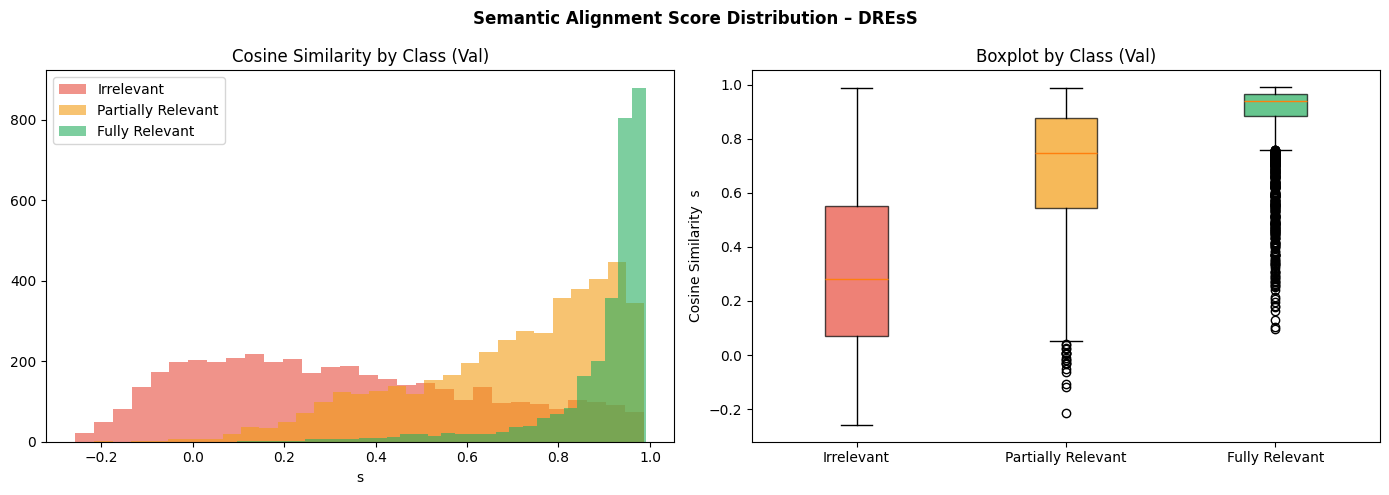

In [18]:
label_names = ["Irrelevant", "Partially Relevant", "Fully Relevant"]
colors      = ["#e74c3c", "#f39c12", "#27ae60"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for lid in range(3):
    m = val_true == lid
    axes[0].hist(val_sims[m], bins=30, alpha=0.6, label=label_names[lid], color=colors[lid])
axes[0].set_title("Cosine Similarity by Class (Val)"); axes[0].set_xlabel("s"); axes[0].legend()

data_by_cls = [val_sims[val_true == i] for i in range(3)]
bp = axes[1].boxplot(data_by_cls, labels=label_names, patch_artist=True)
for patch, c in zip(bp["boxes"], colors): patch.set_facecolor(c); patch.set_alpha(0.7)
axes[1].set_title("Boxplot by Class (Val)"); axes[1].set_ylabel("Cosine Similarity  s")
plt.suptitle("Semantic Alignment Score Distribution – DREsS", fontweight="bold"); plt.tight_layout()
plt.savefig(f"{cfg.OUTPUT_DIR}/similarity_distribution.png", dpi=150, bbox_inches="tight"); plt.show()


## Phase 4 – Threshold Calibration (Grid Search)

In [19]:
def classify(sims, t1, t2):
    preds = np.zeros(len(sims), dtype=int)
    preds[sims >= t1]                    = 2
    preds[(sims >= t2) & (sims < t1)]   = 1
    return preds

def grid_search(sims, true_labels, step=0.01):
    cands = np.arange(float(sims.min()), float(sims.max()), step)
    best  = dict(t1=0.8, t2=0.5, score=0.0)
    for t1 in cands:
        for t2 in cands:
            if t2 >= t1: continue
            p   = classify(sims, t1, t2)
            acc = accuracy_score(true_labels, p)
            wf1 = f1_score(true_labels, p, average="weighted", zero_division=0)
            s   = (acc + wf1) / 2
            if s > best["score"]:
                best.update(t1=t1, t2=t2, score=s)
    return best

print("Running grid search on validation set …")
res   = grid_search(val_sims, val_true, cfg.THRESH_STEP)
θ1    = res["t1"]; θ2 = res["t2"]

print(f"\n{'='*50}")
print(f" θ₁ (Fully Relevant   boundary) : {θ1:.4f}")
print(f" θ₂ (Irrelevant       boundary) : {θ2:.4f}")
print(f" Combined score (acc+wf1)/2     : {res['score']:.4f}")
print(f"\n s ≥ {θ1:.4f}                → Fully Relevant")
print(f" {θ2:.4f} ≤ s < {θ1:.4f}   → Partially Relevant")
print(f" s <  {θ2:.4f}               → Irrelevant")


Running grid search on validation set …



 θ₁ (Fully Relevant   boundary) : 0.9117
 θ₂ (Irrelevant       boundary) : 0.5117
 Combined score (acc+wf1)/2     : 0.6648

 s ≥ 0.9117                → Fully Relevant
 0.5117 ≤ s < 0.9117   → Partially Relevant
 s <  0.5117               → Irrelevant


## Phase 5 – System Evaluation

In [20]:
qc_preds = classify(test_sims, θ1, θ2)

acc  = accuracy_score(test_true, qc_preds)
prec = precision_score(test_true, qc_preds, average="weighted", zero_division=0)
rec  = recall_score(test_true, qc_preds, average="weighted", zero_division=0)
f1m  = f1_score(test_true, qc_preds, average="macro",    zero_division=0)
f1w  = f1_score(test_true, qc_preds, average="weighted", zero_division=0)

print("QualCheck (DREsS) – Test Set"); print("-"*40)
print(f"Accuracy       : {acc:.4f}")
print(f"Precision (W)  : {prec:.4f}")
print(f"Recall    (W)  : {rec:.4f}")
print(f"F1 (macro)     : {f1m:.4f}")
print(f"Weighted F1    : {f1w:.4f}  ({'✓ PASSED' if f1w>=0.80 else '✗ FAILED'}, threshold ≥ 0.80)")
print("\nClassification Report:")
print(classification_report(test_true, qc_preds, target_names=label_names))


QualCheck (DREsS) – Test Set
----------------------------------------
Accuracy       : 0.6638
Precision (W)  : 0.6666
Recall    (W)  : 0.6638
F1 (macro)     : 0.6672
Weighted F1    : 0.6649  (✗ FAILED, threshold ≥ 0.80)

Classification Report:
                    precision    recall  f1-score   support

        Irrelevant       0.74      0.71      0.73      4144
Partially Relevant       0.59      0.62      0.60      4426
    Fully Relevant       0.68      0.67      0.67      2910

          accuracy                           0.66     11480
         macro avg       0.67      0.67      0.67     11480
      weighted avg       0.67      0.66      0.66     11480



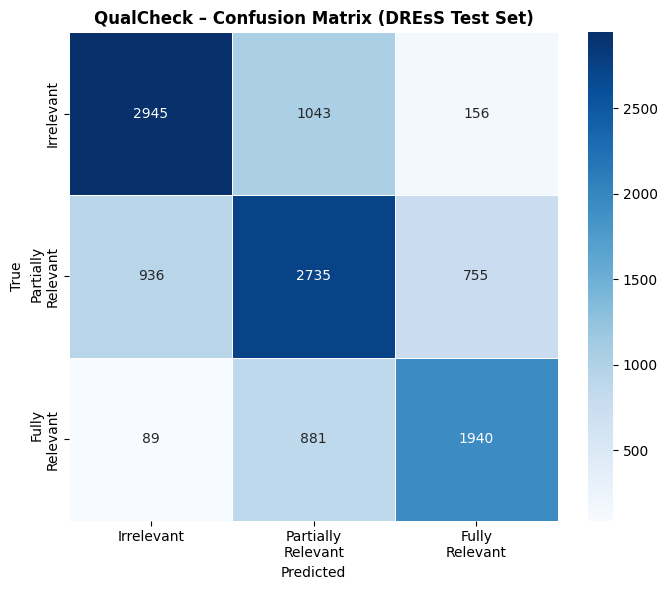

In [21]:
cm = confusion_matrix(test_true, qc_preds)
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Irrelevant","Partially\nRelevant","Fully\nRelevant"],
            yticklabels=["Irrelevant","Partially\nRelevant","Fully\nRelevant"],
            linewidths=0.5)
ax.set_title("QualCheck – Confusion Matrix (DREsS Test Set)", fontweight="bold")
ax.set_ylabel("True"); ax.set_xlabel("Predicted"); plt.tight_layout()
plt.savefig(f"{cfg.OUTPUT_DIR}/confusion_matrix.png", dpi=150, bbox_inches="tight"); plt.show()


### Semantic Alignment Quality (MAE, RMSE, Pearson r)

In [22]:
norm_true = test_true / (cfg.NUM_LABELS - 1)
mae   = np.mean(np.abs(test_sims - norm_true))
rmse  = np.sqrt(np.mean((test_sims - norm_true)**2))
r, pr = pearsonr(test_sims, norm_true)
print(f"MAE        : {mae:.4f}")
print(f"RMSE       : {rmse:.4f}")
print(f"Pearson r  : {r:.4f}  (p={pr:.4f})  {'✓ r≥0.70' if r>=0.70 else '✗ r<0.70'}")


MAE        : 0.2592
RMSE       : 0.3410
Pearson r  : 0.6703  (p=0.0000)  ✗ r<0.70


### Per-Criterion Breakdown

In [23]:
print("Per-Criterion Performance (Test Set)")
print(f"{'Criterion':<16} {'Acc':>6} {'WF1':>6} {'Pearson r':>10} {'n':>6}")
print("-" * 50)

test_df2 = test_df.reset_index(drop=True)
for k in enabled_criteria:
    mask = test_df2["criterion_key"].values == k
    if mask.sum() == 0: continue
    ts   = test_sims[mask]; tl = test_true[mask]; tp = qc_preds[mask]
    nt   = norm_true[mask]
    a    = accuracy_score(tl, tp)
    w    = f1_score(tl, tp, average="weighted", zero_division=0)
    rc,_ = pearsonr(ts, nt) if len(ts) > 2 else (float("nan"), None)
    print(f"{k:<16} {a:>6.4f} {w:>6.4f} {rc:>10.4f} {mask.sum():>6}")


Per-Criterion Performance (Test Set)
Criterion           Acc    WF1  Pearson r      n
--------------------------------------------------
content          0.7152 0.7132     0.7601   2967
organization     0.6276 0.6316     0.6235   6851
language         0.7208 0.7136     0.7348   1662


### Baseline Comparisons

In [24]:
# ── Baseline 1 : TF-IDF ──────────────────────────────────────────
print("--- Baseline 1: TF-IDF Cosine Similarity ---")
tfidf_all = (list(train_df["tfidf_question"] + " " + train_df["tfidf_rubric"]) +
             list(train_df["tfidf_response"]))
tv = TfidfVectorizer(max_features=10_000, ngram_range=(1,2)); tv.fit(tfidf_all)

def tfidf_sims_df(df_sp):
    pr = tv.transform(df_sp["tfidf_question"] + " " + df_sp["tfidf_rubric"])
    r  = tv.transform(df_sp["tfidf_response"])
    return np.array([tfidf_cos(pr[i], r[i])[0,0] for i in range(len(df_sp))])

bl1_vs = tfidf_sims_df(val_df);  bl1_ts = tfidf_sims_df(test_df)
bl1r   = grid_search(bl1_vs, val_true, 0.01)
bl1_p  = classify(bl1_ts, bl1r["t1"], bl1r["t2"])
bl1_acc = accuracy_score(test_true, bl1_p)
bl1_wf1 = f1_score(test_true, bl1_p, average="weighted", zero_division=0)
bl1_r,_ = pearsonr(bl1_ts, norm_true)
bl1_mae = np.mean(np.abs(bl1_ts - norm_true))
print(f"  Acc={bl1_acc:.4f}  WF1={bl1_wf1:.4f}  r={bl1_r:.4f}  MAE={bl1_mae:.4f}")

# ── Baseline 2 : BERT no rubric ───────────────────────────────────
print("--- Baseline 2: BERT without rubric ---")
@torch.no_grad()
def bert_no_rubric(model, df_sp, tokenizer, cfg):
    sims = []
    model.eval()
    for _, row in tqdm(df_sp.iterrows(), total=len(df_sp), desc="  BL2", leave=False):
        q = tokenizer(row["clean_question"], add_special_tokens=True,
            max_length=cfg.MAX_LEN, padding="max_length", truncation=True,
            return_attention_mask=True, return_tensors="pt")
        r = tokenizer(row["clean_response"],  add_special_tokens=True,
            max_length=cfg.MAX_LEN, padding="max_length", truncation=True,
            return_attention_mask=True, return_tensors="pt")
        c = model.similarity(q["input_ids"].to(cfg.DEVICE), q["attention_mask"].to(cfg.DEVICE),
                             r["input_ids"].to(cfg.DEVICE), r["attention_mask"].to(cfg.DEVICE))
        sims.append(c.item())
    return np.array(sims)

bl2_vs = bert_no_rubric(model, val_df,  tokenizer, cfg)
bl2_ts = bert_no_rubric(model, test_df, tokenizer, cfg)
bl2r   = grid_search(bl2_vs, val_true, 0.01)
bl2_p  = classify(bl2_ts, bl2r["t1"], bl2r["t2"])
bl2_acc = accuracy_score(test_true, bl2_p)
bl2_wf1 = f1_score(test_true, bl2_p, average="weighted", zero_division=0)
bl2_r,_ = pearsonr(bl2_ts, norm_true)
bl2_mae = np.mean(np.abs(bl2_ts - norm_true))
print(f"  Acc={bl2_acc:.4f}  WF1={bl2_wf1:.4f}  r={bl2_r:.4f}  MAE={bl2_mae:.4f}")


--- Baseline 1: TF-IDF Cosine Similarity ---


  Acc=0.4722  WF1=0.4399  r=0.2145  MAE=0.3898
--- Baseline 2: BERT without rubric ---


  BL2:   0%|          | 0/11479 [00:00<?, ?it/s]

  BL2:   0%|          | 0/11480 [00:00<?, ?it/s]

  Acc=0.6436  WF1=0.6463  r=0.6515  MAE=0.2677


                System  Accuracy  Weighted F1  Pearson r      MAE  ΔWF1 vs BL1  ΔMAE vs BL1
          BL1 – TF-IDF  0.472213     0.439930   0.214495 0.389768       0.0000       0.0000
BL2 – BERT (no rubric)  0.643554     0.646308   0.651464 0.267749       0.2064      -0.1220
      QualCheck (Ours)  0.663763     0.664885   0.670257 0.259188       0.2250      -0.1306


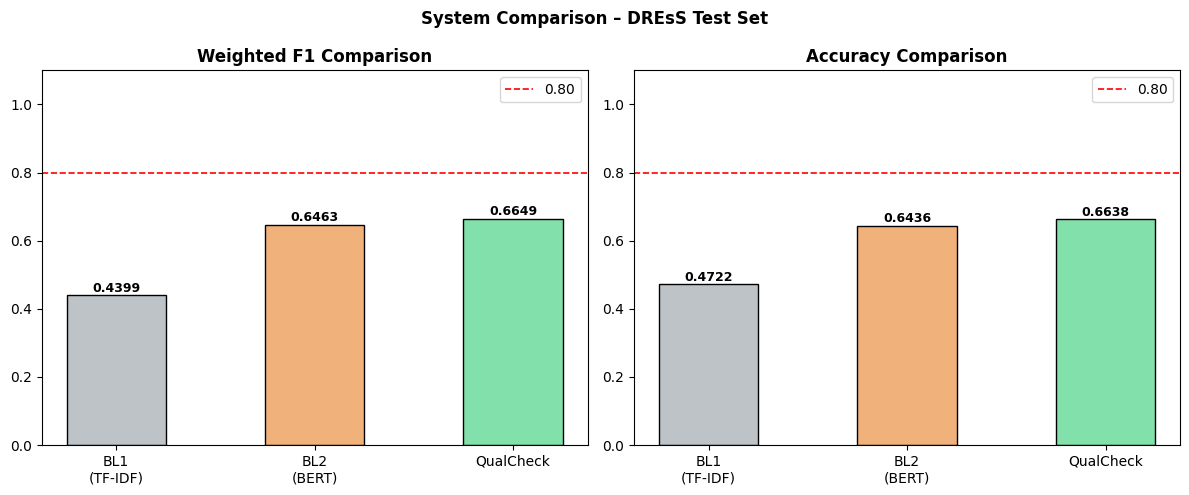

In [25]:
summary = pd.DataFrame({
    "System"      : ["BL1 – TF-IDF", "BL2 – BERT (no rubric)", "QualCheck (Ours)"],
    "Accuracy"    : [bl1_acc, bl2_acc, acc],
    "Weighted F1" : [bl1_wf1, bl2_wf1, f1w],
    "Pearson r"   : [bl1_r,   bl2_r,   r],
    "MAE"         : [bl1_mae, bl2_mae, mae],
    "ΔWF1 vs BL1" : [0.0, round(bl2_wf1-bl1_wf1,4), round(f1w-bl1_wf1,4)],
    "ΔMAE vs BL1" : [0.0, round(bl2_mae-bl1_mae,4), round(mae-bl1_mae,4)],
})
summary.to_csv(f"{cfg.OUTPUT_DIR}/results_summary.csv", index=False)
print(summary.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sys_l  = ["BL1\n(TF-IDF)", "BL2\n(BERT)", "QualCheck"]
colors2 = ["#bdc3c7", "#f0b27a", "#82e0aa"]
for ax, metric in zip(axes, ["Weighted F1", "Accuracy"]):
    vals = summary[metric].tolist()
    bars = ax.bar(sys_l, vals, color=colors2, edgecolor="black", width=0.5)
    ax.set_ylim(0, 1.1); ax.axhline(0.80, color="red", linestyle="--", lw=1.2, label="0.80")
    ax.set_title(f"{metric} Comparison", fontweight="bold"); ax.legend()
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01, f"{v:.4f}",
                ha="center", fontweight="bold", fontsize=9)
plt.suptitle("System Comparison – DREsS Test Set", fontweight="bold"); plt.tight_layout()
plt.savefig(f"{cfg.OUTPUT_DIR}/system_comparison.png", dpi=150, bbox_inches="tight"); plt.show()


### Statistical Tests

In [26]:
print("1. Pearson r (QualCheck)")
print(f"   r={r:.4f}  p={pr:.4f}  {'✓ r≥0.70' if r>=0.70 else '✗ r<0.70'}\n")

print("2. One-Way ANOVA – cross-criterion consistency")
groups = [test_sims[test_df.reset_index(drop=True)["criterion_key"].values == k]
          for k in enabled_criteria]
groups = [g for g in groups if len(g) > 1]
if len(groups) >= 2:
    f_stat, pv = f_oneway(*groups)   # renamed from F -> f_stat so we don't clobber torch.nn.functional's F
    print(f"   F={f_stat:.4f}  p={pv:.4f}")
    if pv > 0.05:
        print("   Non-significant (p>0.05): consistent across criteria ✓")
    else:
        print("   Significant (p≤0.05): Tukey HSD:")
        all_s = np.concatenate(groups)
        all_g = np.concatenate([[k]*len(g) for k, g in zip(enabled_criteria, groups)])
        print(pairwise_tukeyhsd(all_s, all_g, alpha=0.05))

print("\n3. Descriptive Statistics (cosine similarity by class)")
print(f"{'Class':<22} {'Mean':>6} {'Median':>8} {'Std':>6} {'IQR':>6}")
print("-"*50)
for lid, lname in cfg.ID2LABEL.items():
    m = test_true == lid
    if m.any():
        s   = test_sims[m]
        iqr = np.percentile(s,75) - np.percentile(s,25)
        print(f"{lname:<22} {s.mean():>6.4f} {np.median(s):>8.4f} {s.std():>6.4f} {iqr:>6.4f}")

1. Pearson r (QualCheck)
   r=0.6703  p=0.0000  ✗ r<0.70

2. One-Way ANOVA – cross-criterion consistency
   F=71.8368  p=0.0000
   Significant (p≤0.05): Tukey HSD:
   Multiple Comparison of Means - Tukey HSD, FWER=0.05    
 group1     group2    meandiff p-adj lower   upper  reject
----------------------------------------------------------
 content     language  -0.0692   0.0 -0.093 -0.0454   True
 content organization   0.0372   0.0 0.0202  0.0543   True
language organization   0.1064   0.0 0.0852  0.1276   True
----------------------------------------------------------

3. Descriptive Statistics (cosine similarity by class)
Class                    Mean   Median    Std    IQR
--------------------------------------------------
Fully Relevant         0.8929   0.9417 0.1278 0.0824
Partially Relevant     0.6957   0.7499 0.2250 0.3259
Irrelevant             0.3296   0.2941 0.3148 0.4962


## Save Final Model & Predictions

In [27]:
os.makedirs(os.path.dirname(cfg.FINAL_MODEL), exist_ok=True)   # guard: dir may not exist yet
# safetensors only stores tensors, so weights go to .safetensors and the
# non-tensor fields (thresholds, label map, ...) go in a small JSON sidecar.
save_safetensors(model.state_dict(), cfg.FINAL_MODEL)
final_meta = {
    "theta1"      : float(θ1),
    "theta2"      : float(θ2),
    "bert_model"  : cfg.BERT_MODEL,
    "max_len"     : cfg.MAX_LEN,
    "label_map"   : cfg.LABEL2ID,
    "thresh_high" : cfg.THRESH_HIGH,
    "thresh_low"  : cfg.THRESH_LOW,
    "criteria"    : enabled_criteria,
}
with open(cfg.FINAL_META, "w") as f:
    json.dump(final_meta, f, indent=2)

out = test_df[["question","evaluation_criterion","rubric_descriptor",
               "response","raw_score","quality_label","criterion_key"]].copy()
out["cosine_similarity"] = test_sims
out["predicted_label"]   = [cfg.ID2LABEL[p] for p in qc_preds]
out["correct"]           = (test_true == qc_preds)
out.to_csv(f"{cfg.OUTPUT_DIR}/test_predictions.csv", index=False)

print("="*60)
print(" QUALCHECK – DREsS FINAL RESULTS")
print("="*60)
print(f" θ₁ = {θ1:.4f}   θ₂ = {θ2:.4f}")
print(f" Accuracy    : {acc:.4f}")
print(f" Weighted F1 : {f1w:.4f}  ({'✓' if f1w>=0.80 else '✗'} ≥ 0.80)")
print(f" Pearson r   : {r:.4f}  ({'✓' if r>=0.70 else '✗'} ≥ 0.70)")
print(f" MAE         : {mae:.4f}  |  RMSE : {rmse:.4f}")
print(f" ΔWF1 vs BL1 : {f1w-bl1_wf1:+.4f}  |  ΔWF1 vs BL2 : {f1w-bl2_wf1:+.4f}")
print("="*60)
print("✓ QualCheck – DREsS pipeline complete!")


 QUALCHECK – DREsS FINAL RESULTS
 θ₁ = 0.9117   θ₂ = 0.5117
 Accuracy    : 0.6638
 Weighted F1 : 0.6649  (✗ ≥ 0.80)
 Pearson r   : 0.6703  (✗ ≥ 0.70)
 MAE         : 0.2592  |  RMSE : 0.3410
 ΔWF1 vs BL1 : +0.2250  |  ΔWF1 vs BL2 : +0.0186
✓ QualCheck – DREsS pipeline complete!


## Inference Helper – 3-Criteria Aggregation for the Admin Panel UI

Same pattern as Code Report: this model was trained on **one criterion per row** (Content / Organization / Language — same `full_rubric` construction used above: `criterion + ". " + rubric_descriptor`). It has never seen all 3 criteria concatenated into a single input, so the admin panel's 3 rubric boxes can't just be merged into one string at inference time.

`evaluate_essay()` below runs the trained model **3 times** (once per criterion, exactly matching training), then combines the 3 verdicts into one overall result using **weakest-link**: the overall label is the lowest of the 3 per-criterion labels — an essay can't be "Fully Relevant" overall if its Organization is weak, even if Content and Language are both strong.

No dataset changes, no retraining — purely an inference-time wrapper around the model, tokenizer, and calibrated θ₁/θ₂ already in memory. Run the full notebook first, then call `evaluate_essay(...)`.

In [28]:
import torch.nn.functional as F  # re-import in case cell 41 overwrote F with the f_oneway statistic

# Criterion order must match the order the admin panel UI collects the
# 3 rubric boxes in — keep this in sync with the Flet app's field order.
ESSAY_CRITERIA = ["Content", "Organization", "Language"]


@torch.no_grad()
def _single_criterion_similarity_essay(model, tokenizer, cfg, question, full_rubric, response):
    """Encodes P = [CLS] question [SEP] full_rubric [SEP] and R = [CLS] response [SEP],
    matching QualCheckDataset._enc exactly, and returns the cosine similarity."""
    pr = tokenizer(
        question, full_rubric,
        add_special_tokens=True, max_length=cfg.MAX_LEN,
        padding="max_length", truncation=True,
        return_attention_mask=True, return_tensors="pt")
    r = tokenizer(
        response,
        add_special_tokens=True, max_length=cfg.MAX_LEN,
        padding="max_length", truncation=True,
        return_attention_mask=True, return_tensors="pt")

    cos = model.similarity(
        pr["input_ids"].to(cfg.DEVICE),  pr["attention_mask"].to(cfg.DEVICE),
        r["input_ids"].to(cfg.DEVICE),   r["attention_mask"].to(cfg.DEVICE))
    return float(cos.item())


def evaluate_essay(question, criteria_rubrics, response,
                    model, tokenizer, cfg, theta1, theta2,
                    aggregation="weakest_link"):
    """
    Evaluates one essay submission against all 3 rubric criteria and returns
    a single overall verdict, matching what the admin panel's 'Evaluate
    Response' button should call.

    Parameters
    ----------
    question         : the essay prompt (str)
    criteria_rubrics : dict mapping each of ESSAY_CRITERIA to the
                        professor-entered rubric text for that box, e.g.
                        {"Content": "...", "Organization": "...", "Language": "..."}
    response          : the student's essay text (str)
    model, tokenizer, cfg, theta1, theta2 : from the trained pipeline above
    aggregation       : "weakest_link" (default, recommended) takes the lowest
                         of the 3 per-criterion labels as the overall verdict.
                         "average_score" instead averages the 3 cosine similarities
                         and classifies that combined score against theta1/theta2.

    Returns
    -------
    dict with a per-criterion breakdown and one overall verdict.
    """
    model.eval()
    per_criterion = {}

    for criterion in ESSAY_CRITERIA:
        rubric_text = criteria_rubrics.get(criterion, "").strip()
        full_rubric = f"{criterion}. {rubric_text}"   # matches Phase 1 full_rubric construction

        sim      = _single_criterion_similarity_essay(model, tokenizer, cfg, question, full_rubric, response)
        label_id = int(classify(np.array([sim]), theta1, theta2)[0])

        per_criterion[criterion] = {
            "rubric_descriptor"  : rubric_text,
            "cosine_similarity"  : round(sim, 4),
            "predicted_label"    : cfg.ID2LABEL[label_id],
            "label_id"           : label_id,
        }

    if aggregation == "weakest_link":
        overall_label_id = min(v["label_id"] for v in per_criterion.values())
        overall_basis = "lowest of the 3 per-criterion labels"
    elif aggregation == "average_score":
        avg_sim = float(np.mean([v["cosine_similarity"] for v in per_criterion.values()]))
        overall_label_id = int(classify(np.array([avg_sim]), theta1, theta2)[0])
        overall_basis = f"average cosine similarity ({avg_sim:.4f}) reclassified"
    else:
        raise ValueError(f"Unknown aggregation mode: {aggregation}")

    return {
        "per_criterion"  : per_criterion,
        "overall_label"  : cfg.ID2LABEL[overall_label_id],
        "overall_basis"  : overall_basis,
        "aggregation"    : aggregation,
    }


# ── Example usage (mirrors what the Flet app's Evaluate Response handler should do) ──
example_result = evaluate_essay(
    question="Discuss the advantages and disadvantages of studying abroad.",
    criteria_rubrics={
        "Content"     : "Ideas are well-developed, relevant, and supported with strong reasons and examples.",
        "Organization": "The essay is clearly structured with an introduction, body, and conclusion.",
        "Language"    : "Vocabulary and grammar are used accurately and appropriately.",
    },
    response="Studying abroad offers students exposure to new cultures and languages, which broadens "
             "their worldview. However, it can also be costly and challenging to adapt to a new "
             "environment. Overall, the benefits of studying abroad outweigh the drawbacks for most "
             "students who are prepared for the transition.",
    model=model, tokenizer=tokenizer, cfg=cfg, theta1=θ1, theta2=θ2,
)

print("Per-criterion breakdown:")
for crit, res in example_result["per_criterion"].items():
    print(f"  {crit:<14} sim={res['cosine_similarity']:.4f}  →  {res['predicted_label']}")
print(f"\nOverall verdict : {example_result['overall_label']}")
print(f"Basis            : {example_result['overall_basis']}")

Per-criterion breakdown:
  Content        sim=0.8863  →  Partially Relevant
  Organization   sim=0.8513  →  Partially Relevant
  Language       sim=0.9075  →  Partially Relevant

Overall verdict : Partially Relevant
Basis            : lowest of the 3 per-criterion labels
